In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("../../Data/final_clean_data.csv")
df.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_STATE_ABR,DEST,DEST_STATE_ABR,CRS_DEP_TIME,DEP_DELAY,...,DEP_DELAY_GROUP,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,DISTANCE_GROUP,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed
0,4,1,2,AA,GEG,WA,PHX,AZ,6.53,-5.0,...,-1.0,9.33,168.0,1020.0,5,33.0,36.0,89.0,5.0,10.0
1,4,1,2,AA,GEG,WA,PHX,AZ,15.45,15.0,...,1.0,18.12,160.0,1020.0,5,33.0,45.0,63.0,10.0,10.0
2,4,1,2,AA,SEA,WA,CLT,NC,7.33,-3.0,...,-1.0,15.32,299.0,2279.0,10,37.0,43.0,80.0,10.0,6.0
3,4,1,2,AA,SEA,WA,CLT,NC,13.83,-3.0,...,-1.0,21.83,300.0,2279.0,10,41.0,49.0,74.0,10.0,6.0
4,4,1,2,AA,SEA,WA,CLT,NC,22.00,-6.0,...,-1.0,6.00,300.0,2279.0,10,41.0,45.0,86.0,10.0,7.0


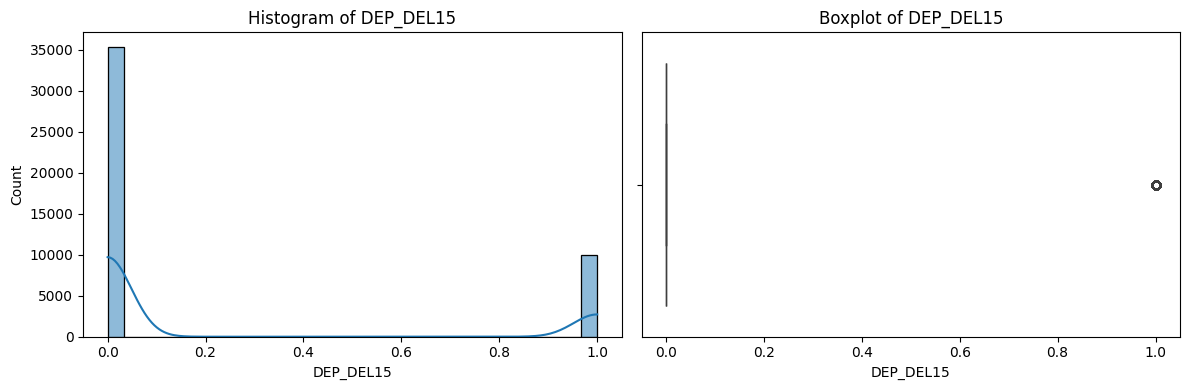

In [3]:
ta_col = ["DEP_DEL15"]

for col in ta_col:
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()


In [4]:
keep_cols = [
    "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK",
    "CRS_DEP_TIME", "CRS_ELAPSED_TIME",
    "OP_UNIQUE_CARRIER", "ORIGIN", "DEST",
    "DISTANCE",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyRelativeHumidity", "HourlyVisibility", "HourlyWindSpeed",
    "DEP_DEL15"
]

flight_dep_model = df[keep_cols].copy()
print("Dataset for flight delay model:", flight_dep_model.shape)
flight_dep_model.head(5)

Dataset for flight delay model: (45251, 15)


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,CRS_ELAPSED_TIME,OP_UNIQUE_CARRIER,ORIGIN,DEST,DISTANCE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed,DEP_DEL15
0,4,1,2,6.53,168.0,AA,GEG,PHX,1020.0,33.0,36.0,89.0,5.0,10.0,0.0
1,4,1,2,15.45,160.0,AA,GEG,PHX,1020.0,33.0,45.0,63.0,10.0,10.0,1.0
2,4,1,2,7.33,299.0,AA,SEA,CLT,2279.0,37.0,43.0,80.0,10.0,6.0,0.0
3,4,1,2,13.83,300.0,AA,SEA,CLT,2279.0,41.0,49.0,74.0,10.0,6.0,0.0
4,4,1,2,22.00,300.0,AA,SEA,CLT,2279.0,41.0,45.0,86.0,10.0,7.0,0.0


In [5]:
label_cols = ["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"]
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    flight_dep_model[col] = le.fit_transform(flight_dep_model[col])
    label_encoders[col] = le
    print(f" {col}: {len(le.classes_)} categories encoded.")

flight_dep_tree = flight_dep_model[keep_cols]

print("\n Dataset after Label Encoding:")
print("Number of rows:", flight_dep_tree.shape[0])
print("Number of columns:", flight_dep_tree.shape[1])
print("\n Sample of encoded categorical features:")
print(flight_dep_tree.dtypes.value_counts())

print(flight_dep_tree.head(5))

flight_dep_tree.to_csv("../../Data/Classi_Data/flight_dep_classi_tree.csv", index=False)

 OP_UNIQUE_CARRIER: 12 categories encoded.
 ORIGIN: 5 categories encoded.
 DEST: 86 categories encoded.

 Dataset after Label Encoding:
Number of rows: 45251
Number of columns: 15

 Sample of encoded categorical features:
float64    9
int64      6
Name: count, dtype: int64
   MONTH  DAY_OF_MONTH  DAY_OF_WEEK  CRS_DEP_TIME  CRS_ELAPSED_TIME  \
0      4             1            2          6.53             168.0   
1      4             1            2         15.45             160.0   
2      4             1            2          7.33             299.0   
3      4             1            2         13.83             300.0   
4      4             1            2         22.00             300.0   

   OP_UNIQUE_CARRIER  ORIGIN  DEST  DISTANCE  HourlyDewPointTemperature  \
0                  0       1    62    1020.0                       33.0   
1                  0       1    62    1020.0                       33.0   
2                  0       4    14    2279.0                       37.0   

In [6]:
import joblib

# Lưu encoder để dùng lại ở app.py
joblib.dump(label_encoders, "../../Classi_Models/label_encoders.pkl")

['../../Classi_Models/label_encoders.pkl']